Installation of xgboost

In [1]:
!pip install xgboost

Importing all the necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score,accuracy_score,classification_report,confusion_matrix)
from xgboost import XGBRegressor, XGBClassifier

Loading the raw dataset

In [3]:
df = pd.read_csv("real_estate_raw.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (1800, 17)


,Total_Square_Footage,Bedrooms,Bathrooms,Age_of_Property,Floor_Number,Furnishing_Status,Neighborhood,Distance_to_City_Center_km,Proximity_to_Public_Transport_km,Crime_Index,Air_Quality_Index,Neighborhood_Growth_Rate_%,Price_per_SqFt,Annual_Property_Tax,Estimated_Rental_Yield_%,Current_Market_Price,Investment_Grade
0,1748.357077,5,3,26,7,Unfurnished,Suburban,16.481757,2.129420,45.0,250.0,4.885652,3839.671746,92506.474881,9.980046,6.713117e+06,0
1,1430.867849,3,4,0,11,Fully-furnished,IT Hub,5.668308,1.415320,82.0,216.0,10.576260,6685.917558,159676.200083,9.828702,9.566664e+06,0
2,1823.844269,3,3,26,2,Semi-furnished,Suburban,13.200650,0.840190,31.0,79.0,8.908252,4759.509657,163275.582676,8.230588,8.680604e+06,1
3,2261.514928,3,4,15,16,Semi-furnished,Suburban,3.672011,0.407293,10.0,226.0,7.691113,4522.943402,167067.631077,2.160537,1.022870e+07,1
4,NaN,5,3,37,20,Unfurnished,Suburban,1.068966,0.225101,78.0,245.0,13.180594,6990.013738,146136.173947,6.347799,9.666653e+06,0


Understanding the Numerical Columns

In [8]:
df.select_dtypes('number').columns

Index(['Total_Square_Footage', 'Bedrooms', 'Bathrooms', 'Age_of_Property',
       'Floor_Number', 'Furnishing_Status', 'Distance_to_City_Center_km',
       'Proximity_to_Public_Transport_km', 'Crime_Index', 'Air_Quality_Index',
       'Neighborhood_Growth_Rate_%', 'Price_per_SqFt', 'Annual_Property_Tax',
       'Estimated_Rental_Yield_%', 'Current_Market_Price', 'Investment_Grade'],
      dtype='object')

# Handling Missing Values

Fill numeric columns with median

In [4]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Encoding Categorical Columns

Furnishing Status (Ordinal Encoding)

In [5]:
furnish_map = {
    'Unfurnished': 0,
    'Semi-furnished': 1,
    'Fully-furnished': 2
}

df['Furnishing_Status'] = df['Furnishing_Status'].map(furnish_map)

One-Hot Encode Neighborhood

In [6]:
df = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True)

Outlier Treatment (IQR Method)

In [7]:
for col in num_cols:
    if col not in ['Current_Market_Price', 'Investment_Grade']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = np.clip(df[col], lower, upper)

Saving the cleaned dataset

In [9]:
df.to_csv("real_estate_clean.csv", index=False)

Cleaned Dataset

In [10]:
df = pd.read_csv("real_estate_clean.csv")
df.head()

,Total_Square_Footage,Bedrooms,Bathrooms,Age_of_Property,Floor_Number,Furnishing_Status,Distance_to_City_Center_km,Proximity_to_Public_Transport_km,Crime_Index,Air_Quality_Index,Neighborhood_Growth_Rate_%,Price_per_SqFt,Annual_Property_Tax,Estimated_Rental_Yield_%,Current_Market_Price,Investment_Grade,Neighborhood_IT Hub,Neighborhood_Industrial,Neighborhood_Residential,Neighborhood_Suburban
0,1748.357077,5,3,26,7,0.0,16.481757,2.129420,45.0,250.0,4.885652,3839.671746,92506.474881,9.980046,6.713117e+06,0,False,False,False,True
1,1430.867849,3,4,0,11,2.0,5.668308,1.415320,82.0,216.0,10.576260,6685.917558,159676.200083,9.828702,9.566664e+06,0,True,False,False,False
2,1823.844269,3,3,26,2,1.0,13.200650,0.840190,31.0,79.0,8.908252,4759.509657,163275.582676,8.230588,8.680604e+06,1,False,False,False,True
3,2261.514928,3,4,15,16,1.0,3.672011,0.407293,10.0,226.0,7.691113,4522.943402,167067.631077,2.160537,1.022870e+07,1,False,False,False,True
4,1528.805461,5,3,37,20,0.0,1.068966,0.225101,78.0,245.0,13.180594,6990.013738,146136.173947,6.347799,9.666653e+06,0,False,False,False,True


#XGBoost Regression (Predict Price)

Defining Features

In [11]:
X_reg = df.drop(columns=['Current_Market_Price', 'Investment_Grade'])
y_reg = df['Current_Market_Price']

Train Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

Scaling

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler_reg = MinMaxScaler()

X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

Train XGBoost

In [15]:
from xgboost import XGBRegressor

reg_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

reg_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluation

In [18]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = reg_model.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9483419689015626
MAE: 550850.8172951103
RMSE: 1010636.0140204072


Feature Importance (Required for Price Driver Analysis)

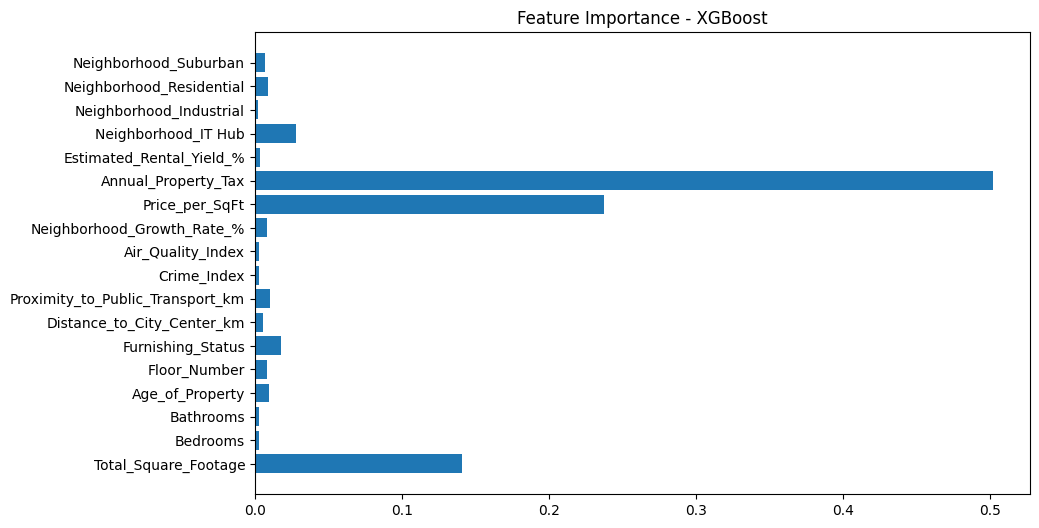

In [19]:
import matplotlib.pyplot as plt

importances = reg_model.feature_importances_
features = X_reg.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance - XGBoost")
plt.show()

#XGBoost Classification (Investment Grade)

In [20]:
from xgboost import XGBClassifier

Define Features & Target

In [23]:
#Removing Current_Market_Price so model doesn’t cheat and is more accurate.
X_clf = df.drop(columns=['Investment_Grade', 'Current_Market_Price'])
y_clf = df['Investment_Grade']


Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

Scaling

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler_clf = MinMaxScaler()

X_train_scaled_c = scaler_clf.fit_transform(X_train_c)
X_test_scaled_c = scaler_clf.transform(X_test_c)

Train XGBoost Classifier

In [26]:
clf_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

clf_model.fit(X_train_scaled_c, y_train_c)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:18:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Evaluate Classification

In [30]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_c = clf_model.predict(X_test_scaled_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("\nClassification Report:\n")
print(classification_report(y_test_c, y_pred_c))

Accuracy: 0.975

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       167
           1       0.96      0.99      0.98       171
           2       1.00      0.91      0.95        22

    accuracy                           0.97       360
   macro avg       0.98      0.96      0.97       360
weighted avg       0.98      0.97      0.97       360



Confusion Matrix

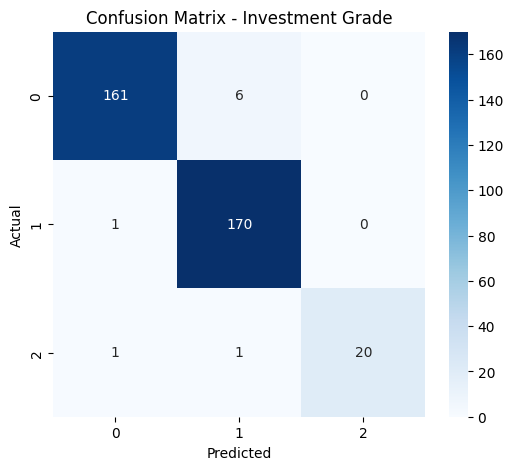

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_c = clf_model.predict(X_test_scaled_c)
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Investment Grade")
plt.show()

#Feature Importance (Classification)

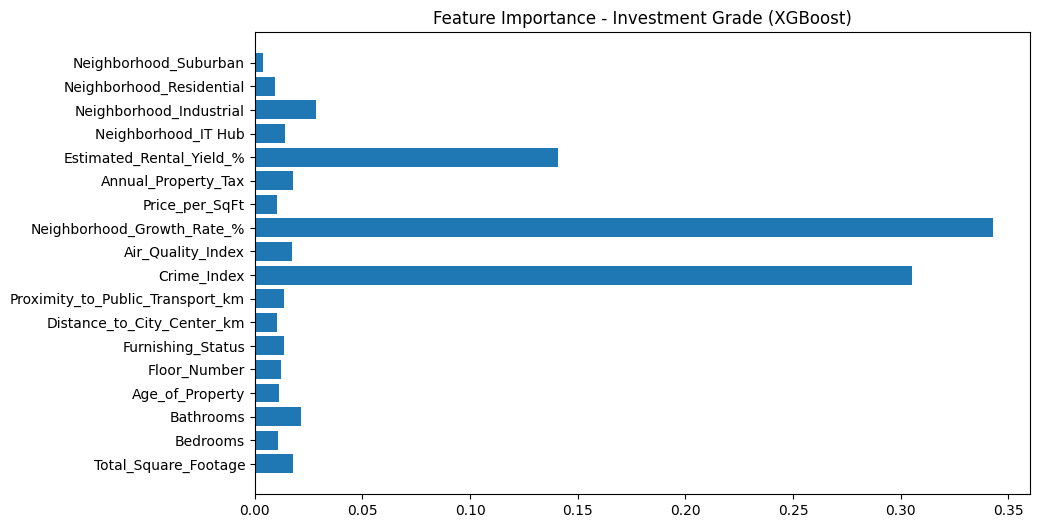

In [29]:
importances_clf = clf_model.feature_importances_
features_clf = X_clf.columns

plt.figure(figsize=(10,6))
plt.barh(features_clf, importances_clf)
plt.title("Feature Importance - Investment Grade (XGBoost)")
plt.show()

Saving models

In [31]:
import joblib

joblib.dump(reg_model, "xgb_regression_model.joblib")
joblib.dump(scaler_reg, "regression_scaler.joblib")

joblib.dump(clf_model, "xgb_classification_model.joblib")
joblib.dump(scaler_clf, "classification_scaler.joblib")

['classification_scaler.joblib']

Sample Testing

In [51]:
sample = X_test.iloc[[78]]

sample_scaled_reg = scaler_reg.transform(sample)
predicted_price = reg_model.predict(sample_scaled_reg)[0]

sample_clf = X_test_c.iloc[[0]]
sample_scaled_clf = scaler_clf.transform(sample_clf)
predicted_grade = clf_model.predict(sample_scaled_clf)[0]

print("Predicted Price:", predicted_price)
print("Predicted Investment Grade:", predicted_grade)

Predicted Price: 16749228.0
Predicted Investment Grade: 1
